# TCEV mixture model: Capturing Extraordinary Floods

The Two-Component Extreme Value (TCEV) model represents the AMS as a mixture of two populations: ordinary and extraordinary floods.

In [1]:
import pandas as pd
import numpy as np
import arviz as az
import matplotlib.pyplot as plt
from flood_ffa.data.bom import load_ams, get_flow_series
from flood_ffa.tcev.fit import fit_tcev
from flood_ffa.tcev.plots import plot_trace, plot_corner, plot_return_levels, plot_component_separation

## The 2021 Outlier

The 2021 flood (121.9 m3/s) is nearly double the next highest value. TCEV is designed to handle such events without inflating the shape parameter of the entire population.

In [2]:
df = load_ams("../data/AMS.csv")
flows = get_flow_series(df)

## Mixture Model Fitting

We use a higher `target_accept=0.9` for sampling stability and an ordering constraint `mu1 < mu2` to prevent label switching.

In [3]:
idata_tcev = fit_tcev(flows, draws=2000, tune=1000)

Initializing NUTS using jitter+adapt_diag...
E:\GitHub\pyFloodExtremes\.venv\Lib\site-packages\pytensor\link\c\cmodule.py:2986: UserWarning: PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that perform their own BLAS optimizations, by setting `pytensor.config.mode == 'NUMBA'` or passing `mode='NUMBA'` when compiling a PyTensor function.
For more options and details see https://pytensor.readthedocs.io/en/latest/troubleshooting.html#how-do-i-configure-test-my-blas-library
  warnings.warn(
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [w, mu1, sigma1, xi1, mu2, sigma2, xi2]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 56 seconds.
There were 2157 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


## Posterior Diagnostics

We monitor the mixing of all 7 parameters.

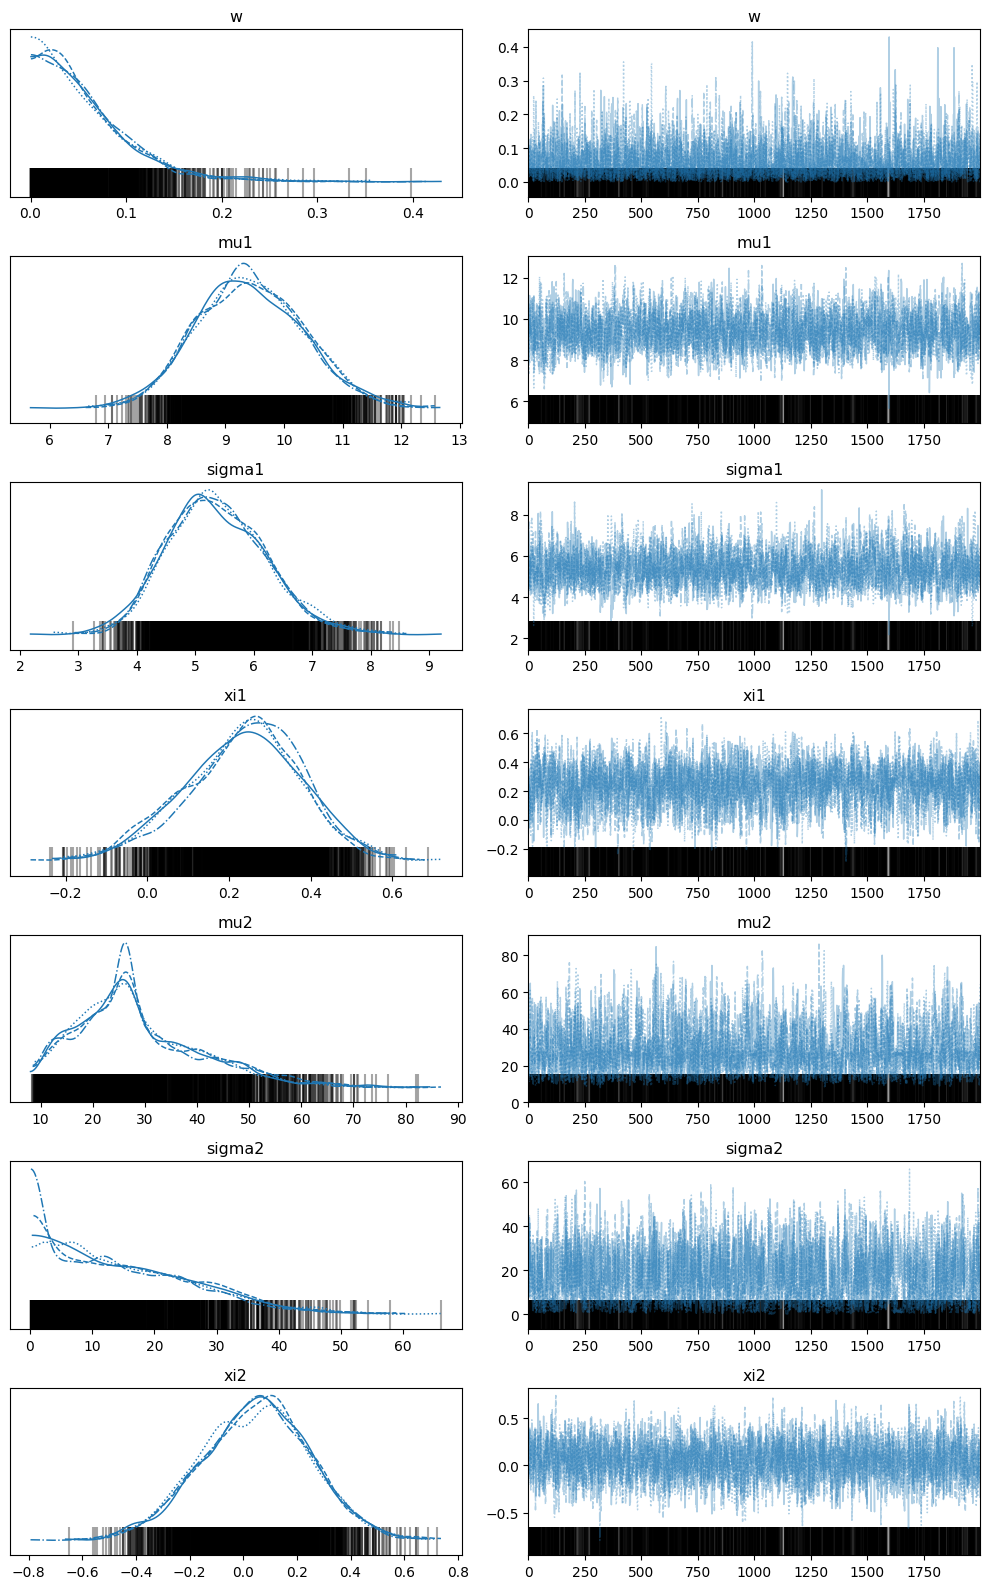

In [4]:
plot_trace(idata_tcev);
plt.show()

## Mixture Frequency Curve

The mixture curve often shows a "kink" where the extraordinary component begins to dominate the tail.

E:\GitHub\pyFloodExtremes\src\flood_ffa\tcev\plots.py:35: RuntimeWarning: overflow encountered in power
  cdf[valid] = np.exp(-(cond[valid] ** (-1/xi)))
E:\GitHub\pyFloodExtremes\src\flood_ffa\tcev\plots.py:82: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  n_chains = idata.posterior.dims['chain']
E:\GitHub\pyFloodExtremes\src\flood_ffa\tcev\plots.py:83: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  n_draws = idata.posterior.dims['draw']


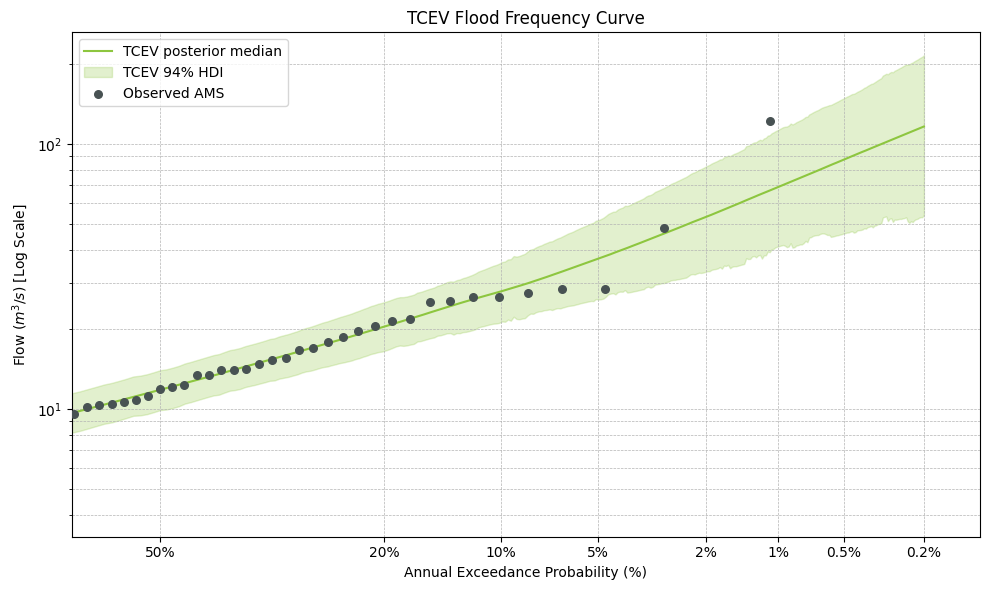

In [5]:
plot_return_levels(idata_tcev, flows);
plt.show()

## Component Separation

We can calculate the probability that each observed year belongs to the "extraordinary" component (Component 2).

E:\GitHub\pyFloodExtremes\src\flood_ffa\tcev\plots.py:148: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  n_chains = idata.posterior.dims['chain']
E:\GitHub\pyFloodExtremes\src\flood_ffa\tcev\plots.py:149: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  n_draws = idata.posterior.dims['draw']


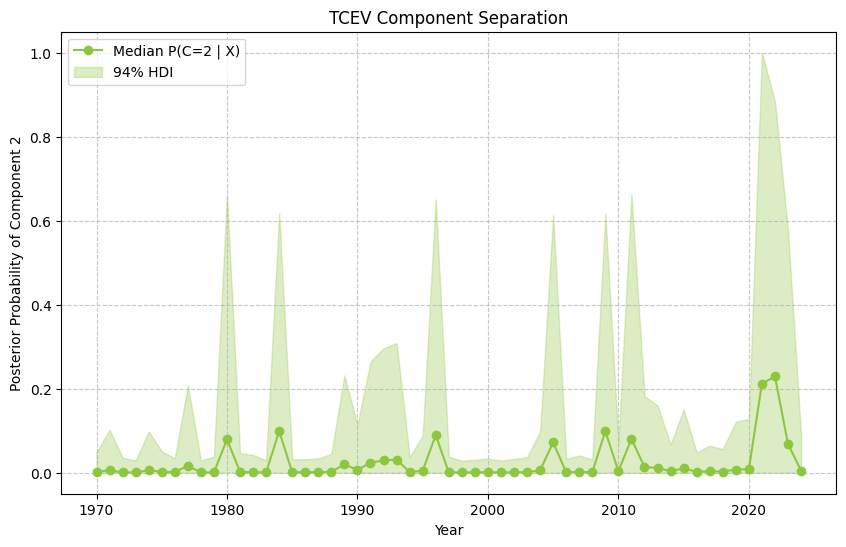

In [6]:
plot_component_separation(idata_tcev, flows);
plt.show()

## Scientific Narrative

The 2021 event should show a very high probability of belonging to Component 2, providing empirical support for the mixture model approach.